# Game of Thrones: Pandas Are Coming

## 1. Import Libraries and Dependencies

In [1]:
# Import necessary libraries and dependencies
import pandas as pd
from pathlib import Path

## 2. Set File Path to CSV using Pathlib

In [2]:
# Save file path to variable
got_path = "../Resources/game_of_thrones.csv"

## 3. Import CSV into Pandas DataFrame

In [3]:
# Read csv with Pandas
got_df = pd.read_csv(got_path)
got_df.head()

,Name,Allegiances,Death Year,Book of Death,Death Chapter,Book Intro Chapter,Gender,Nobility,GoT,CoK,SoS,FfC,DwD
0,Addam Marbrand,Lannister,NaN,NaN,NaN,56.0,1,1,1,1,1,1,0
1,Aegon Frey (Jinglebell),None,299.0,3.0,51.0,49.0,1,1,0,0,1,0,0
2,Aegon Targaryen,House Targaryen,NaN,NaN,NaN,5.0,1,1,0,0,0,0,1
3,Adrack Humble,House Greyjoy,300.0,5.0,20.0,20.0,1,1,0,0,0,0,1
4,Aemon Costayne,Lannister,NaN,NaN,NaN,NaN,1,1,0,0,1,0,0


## 4. Count Unique Allegiances

In [4]:
# Collect a list of all the unique values in "Allegiances"
got_df["Allegiances"].unique()

array(['Lannister', 'None', 'House Targaryen', 'House Greyjoy',
       'Baratheon', "Night's Watch", 'Arryn', 'House Stark',
       'House Tyrell', 'Tyrell', 'Stark', 'Greyjoy', 'House Lannister',
       'Martell', 'House Martell', 'Wildling', 'Targaryen', 'House Arryn',
       'House Tully', 'Tully', 'House Baratheon'], dtype=object)

## 5. Filter to Only Allegiances and Names

In [5]:
# Create a new table with only the Allegiances and Names
got_houses_df = got_df[["Allegiances", "Name"]]
got_houses_df.head()

,Allegiances,Name
0,Lannister,Addam Marbrand
1,None,Aegon Frey (Jinglebell)
2,House Targaryen,Aegon Targaryen
3,House Greyjoy,Adrack Humble
4,Lannister,Aemon Costayne


## 6. Groupby Allegiances and Count the number of Members

In [6]:
# Create a GroupBy object based on the "Allegiances" column in the newley created table
got_houses = got_houses_df.groupby(["Allegiances"])

got_house_count = got_houses.count()
got_house_count

,Name
Allegiances,
Arryn,23
Baratheon,56
Greyjoy,51
House Arryn,7
House Baratheon,8
House Greyjoy,24
House Lannister,21
House Martell,12
House Stark,35


## 7. Rename Column from `Name` to `Members`

In [7]:
# Use the `rename` function to change the `Name` column to `Members`
got_house_count.columns = ["Members"]
got_house_count

,Members
Allegiances,
Arryn,23
Baratheon,56
Greyjoy,51
House Arryn,7
House Baratheon,8
House Greyjoy,24
House Lannister,21
House Martell,12
House Stark,35


## 8. Sort House Member Count in Descending Order

In [8]:
# Sort by most deaths and reset index
got_house_count.sort_values(["Members"], ascending=False, inplace=True)

## 9. Select the 2nd Largest Allegiance via iloc

In [30]:
# Save the death count for the Night's Watch, using `iloc` to filter
nights_watch = got_house_count.iloc[1]
nights_watch

Members    116
Name: Night's Watch, dtype: int64

<AxesSubplot: xlabel='Allegiances'>

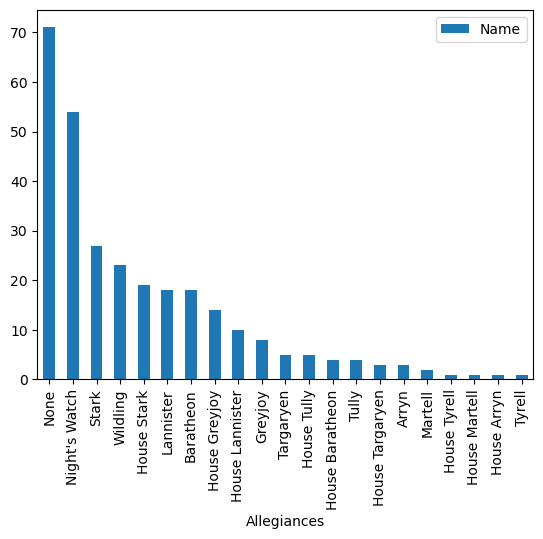

In [9]:
# Read csv with Pandas
got_df = pd.read_csv(got_path)
got_death = got_df.dropna()
gdf = got_death.groupby('Allegiances').count().sort_values("Name",ascending=False)
gdfp = gdf[['Name']]
gdfp.plot.bar()